In [1]:
import os
import pickle
import pandas as pd
import numpy as np
from numpy.random import default_rng
import pyarrow.csv as pv
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score, confusion_matrix, precision_recall_curve, average_precision_score, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import shap
import shapash
import matplotlib
import optuna

/depot/pbaloni/data/Lab_members/Boyu_Jiang/Software/.conda/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
data = pv.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/Flux_Sampling_01162025/EN_100sample.csv')
data = data.to_pandas()
data.set_index(data.columns[0], inplace=True)

core_rxn = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Code/ML_final_code/core_reaction_remove_allTrans.csv')
core_rxn = core_rxn['core_reaction_remove_allTrans'].to_list()

core_rxn = core_rxn + data.columns[-3:].to_list()
data = data[core_rxn]
data_annoted = data
data_annoted

,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,Sex,Age_of_Death,BRAAK_AD
,,,,,,,,,,,,,,,,,,,,,
AMPAD_HBCC_0000000373_EN_174,NaN,0.180120,NaN,NaN,None,NaN,-9.299715,None,None,0.260489,...,1.553755,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_722,NaN,0.933717,NaN,NaN,None,NaN,-11.019860,None,None,1.140337,...,2.394480,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_769,NaN,0.547359,NaN,NaN,None,NaN,-11.828869,None,None,1.171461,...,3.524314,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_504,NaN,0.529390,NaN,NaN,None,NaN,-11.887466,None,None,0.366530,...,2.419622,NaN,NaN,None,NaN,None,NaN,male,36,NaN
AMPAD_HBCC_0000000373_EN_276,NaN,0.374135,NaN,NaN,None,NaN,-10.235425,None,None,0.094135,...,2.153978,NaN,NaN,None,NaN,None,NaN,male,36,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_MSSM_0000991331_EN_436,NaN,0.455249,NaN,NaN,None,NaN,-11.181420,None,None,0.425278,...,3.448971,NaN,-1.567704,None,NaN,None,NaN,male,59,0.0
AMPAD_MSSM_0000991331_EN_764,NaN,0.481180,NaN,NaN,None,NaN,-13.315789,None,None,0.391512,...,2.548774,NaN,-0.600379,None,NaN,None,NaN,male,59,0.0
AMPAD_MSSM_0000991331_EN_88,NaN,0.292305,NaN,NaN,None,NaN,-11.614931,None,None,0.307242,...,0.545245,NaN,-1.505730,None,NaN,None,NaN,male,59,0.0


In [3]:
NPS_AD_metadata = pd.read_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/NPS-AD_neuropathology_and_diagnosis_metadata.csv')

In [8]:
scz = []
for i in data_annoted.index:
    #sample_name = i.split("_IN_")[0]
    sample_name = i.split("_EN_")[0]
    scz_class = NPS_AD_metadata[NPS_AD_metadata['IndividualID']==sample_name]['SCZ'].to_list()[0]
    scz.append(scz_class)
    
data_annoted['SCZ'] = scz

/tmp/ipykernel_830505/4211050349.py:8: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



In [16]:
# Grouging based on SCZ

G_0 =  data_annoted[data_annoted['SCZ'].isin([0])]
# sample the scz 0
G_0 = G_0.sample(n=18100, random_state=42)

G_1 =  data_annoted[data_annoted['SCZ'].isin([1])]

# Comparsion groups
data_G0_G1 = pd.concat([G_0, G_1], ignore_index=False)
data_G0_G1.fillna(0, inplace=True)


/tmp/ipykernel_830505/4043288284.py:16: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [17]:
data_G0_G1

,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,Sex,Age_of_Death,BRAAK_AD,SCZ
,,,,,,,,,,,,,,,,,,,,,
AMPAD_MSSM_0000077549_EN_521,0.0,1.462950,0.0,0.796232,0,0.0,-4.270616,0,0,1.545885,...,0.0,0.0,0,0.0,0,0.000000,male,89+,2.0,0
AMPAD_MSSM_0000071187_EN_275,0.0,1.479197,0.0,0.000000,0,0.0,-8.857432,0,0,3.455322,...,0.0,0.0,0,0.0,0,0.000856,male,89+,3.0,0
AMPAD_MSSM_0000340452_EN_859,0.0,0.982163,0.0,0.000000,0,0.0,-9.390940,0,0,0.000000,...,0.0,0.0,0,0.0,0,0.000000,male,89+,4.0,0
AMPAD_MSSM_0000042055_EN_451,0.0,2.116122,0.0,0.910982,0,0.0,-1.971951,0,0,1.532204,...,0.0,0.0,0,0.0,0,0.001265,female,85,2.0,0
AMPAD_MSSM_0000070658_EN_548,0.0,1.557580,0.0,0.730374,0,0.0,-9.579307,0,0,2.170330,...,0.0,0.0,0,0.0,0,0.000000,female,88,6.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_HBCC_0000000448_EN_436,0.0,1.647392,0.0,0.195229,0,0.0,-0.316823,0,0,0.978783,...,0.0,0.0,0,0.0,0,0.000814,female,48,0.0,1
AMPAD_HBCC_0000000448_EN_764,0.0,2.977274,0.0,0.867325,0,0.0,-2.420416,0,0,0.442471,...,0.0,0.0,0,0.0,0,0.000932,female,48,0.0,1
AMPAD_HBCC_0000000448_EN_88,0.0,1.586071,0.0,0.846646,0,0.0,-4.653852,0,0,0.801324,...,0.0,0.0,0,0.0,0,0.000741,female,48,0.0,1


## Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.preprocessing import MinMaxScaler

In [18]:
data_HT_AD = data_G0_G1
data_HT_AD.fillna(0, inplace=True)
data_HT_AD.drop(data_HT_AD.columns[-4:-1], axis=1, inplace=True)
filtered_df = data_HT_AD
del data_HT_AD
filtered_df

,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_4mop_m,DM_pheme_m,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,SCZ
,,,,,,,,,,,,,,,,,,,,,
AMPAD_MSSM_0000077549_EN_521,0.0,1.462950,0.0,0.796232,0,0.0,-4.270616,0,0,1.545885,...,0.0,0.0,0.793557,0.0,0.0,0,0.0,0,0.000000,0
AMPAD_MSSM_0000071187_EN_275,0.0,1.479197,0.0,0.000000,0,0.0,-8.857432,0,0,3.455322,...,0.0,0.0,1.383083,0.0,0.0,0,0.0,0,0.000856,0
AMPAD_MSSM_0000340452_EN_859,0.0,0.982163,0.0,0.000000,0,0.0,-9.390940,0,0,0.000000,...,0.0,0.0,1.967543,0.0,0.0,0,0.0,0,0.000000,0
AMPAD_MSSM_0000042055_EN_451,0.0,2.116122,0.0,0.910982,0,0.0,-1.971951,0,0,1.532204,...,0.0,0.0,1.959734,0.0,0.0,0,0.0,0,0.001265,0
AMPAD_MSSM_0000070658_EN_548,0.0,1.557580,0.0,0.730374,0,0.0,-9.579307,0,0,2.170330,...,0.0,0.0,0.613365,0.0,0.0,0,0.0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_HBCC_0000000448_EN_436,0.0,1.647392,0.0,0.195229,0,0.0,-0.316823,0,0,0.978783,...,0.0,0.0,2.541072,0.0,0.0,0,0.0,0,0.000814,1
AMPAD_HBCC_0000000448_EN_764,0.0,2.977274,0.0,0.867325,0,0.0,-2.420416,0,0,0.442471,...,0.0,0.0,1.702069,0.0,0.0,0,0.0,0,0.000932,1
AMPAD_HBCC_0000000448_EN_88,0.0,1.586071,0.0,0.846646,0,0.0,-4.653852,0,0,0.801324,...,0.0,0.0,0.051689,0.0,0.0,0,0.0,0,0.000741,1


In [19]:
feature_columns = filtered_df.columns.to_list()[:filtered_df.shape[1]-1]

target_column = 'SCZ'

X = filtered_df[feature_columns]
y = filtered_df[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)

In [24]:
def hyperopt_obj(params):
    C = params['C']
    max_iter = params['max_iter']
    solver = params['solver']
    
    model = LogisticRegression(C=C, 
                               penalty='l2',
                               max_iter=max_iter, 
                               solver=solver, 
                               #class_weight='balanced', 
                               random_state=42)
    
  
    
    model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
        
    accuracy = accuracy_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

        
        
    return {"loss": -roc_auc, "status": STATUS_OK}

space = {
    'C': hp.loguniform("C", np.log(0.000001), np.log(0.01)),
    'max_iter':  hp.randint('max_iter', 200, 2000),
    'solver': hp.choice('solver', ['lbfgs', 'liblinear'])
}

trials = Trials()
best_LR = fmin(
    fn = hyperopt_obj,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
)

  0%|                                    | 0/50 [00:00<?, ?trial/s, best loss=?]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.000522 seconds
INFO:hyperopt.tpe:TPE using 0 trials


  2%|▏         | 1/50 [00:03<02:27,  3.01s/trial, best loss: -0.695418180153231]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.000595 seconds
INFO:hyperopt.tpe:TPE using 1/1 trials with best loss -0.695418


  4%|▍         | 2/50 [00:04<01:55,  2.40s/trial, best loss: -0.760552791428833]

...

 96%|████████▋| 48/50 [01:27<00:03,  1.94s/trial, best loss: -0.798516834040475]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.000578 seconds
INFO:hyperopt.tpe:TPE using 48/48 trials with best loss -0.798517


 98%|████████▊| 49/50 [01:31<00:02,  2.73s/trial, best loss: -0.798516834040475]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.000771 seconds
INFO:hyperopt.tpe:TPE using 49/49 trials with best loss -0.798517


100%|█████████| 50/50 [01:32<00:00,  1.85s/trial, best loss: -0.798516834040475]


In [25]:
from sklearn.model_selection import cross_val_score

final_model = LogisticRegression(C=best_LR['C'], 
                           max_iter=best_LR['max_iter'], 
                           penalty='l2',      
                           random_state=42, 
                           #class_weight='balanced',
                           solver=['lbfgs', 'liblinear'][best_LR['solver']])
                           
Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
Accuracy = []
F1_score = []
AUC = []
Recall = []
Precision = []
PR_AUC = []
Kappa = []
results = []
fold_num = 0

for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    
    final_model.fit(X_val_train, y_val_train)
    y_pred = final_model.predict(X_val_test)
    y_prob = final_model.predict_proba(X_val_test)[:, 1]  # Probabilities for the positive class (class 1)
    
    accuracy = accuracy_score(y_val_test, y_pred)
    kappa = cohen_kappa_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    pr_auc = average_precision_score(y_val_test, y_prob)
    roc_auc = roc_auc_score(y_val_test, y_prob)
    
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc
    })
    

    
results_df = pd.DataFrame(results)
average_results = {
        "Fold": 'Average',
        "Accuracy": results_df['Accuracy'].mean(),
        "F1-score": results_df['F1-score'].mean(),
        "Recall": results_df['Recall'].mean(),
        "Precision": results_df['Precision'].mean(),
        "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
        "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
    }
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

''' 
    Accuracy.append(accuracy)
    F1_score.append(f1)
    Kappa.append(kappa)
    AUC.append(roc_auc)
    Recall.append(recall)
    Precision.append(precision)
    PR_AUC.append(pr_auc)
'''
results_df


/tmp/ipykernel_830505/1670566897.py:24: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/1670566897.py:24: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/1670566897.py:24: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/1670566897.py:24: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as l

,Fold,Accuracy,F1-score,Recall,Precision,Precision-Recall AUC,AUC (ROC Curve)
0,1,0.720166,0.726290,0.742541,0.710735,0.777708,0.802636
1,2,0.719337,0.723462,0.734254,0.712983,0.772581,0.795287
2,3,0.722652,0.727322,0.739779,0.715278,0.777965,0.798224
3,4,0.728453,0.733098,0.745856,0.720769,0.792373,0.808691
4,5,0.723204,0.728749,0.743646,0.714437,0.777448,0.800203
5,6,0.718508,0.720285,0.724862,0.715767,0.774326,0.793417
6,7,0.729558,0.733460,0.744199,0.723027,0.787126,0.806272
7,8,0.724309,0.725824,0.729834,0.721858,0.775441,0.798394
8,9,0.721823,0.726582,0.739227,0.714362,0.765689,0.791815
9,10,0.720166,0.723602,0.732597,0.714825,0.781996,0.798915


In [26]:
final_model = LogisticRegression(C=best_LR['C'], 
                           max_iter=best_LR['max_iter'], 
                           penalty='l2',      
                           random_state=42, 
                           class_weight='balanced',
                           solver=['lbfgs', 'liblinear'][best_LR['solver']]
                           
                          )

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)


# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# 3. F1 Score
f1 = f1_score(y_test, y_pred)

# 4. Recall
recall = recall_score(y_test, y_pred)

# 5. Precision
precision = precision_score(y_test, y_pred)

# 6. Precision-Recall AUC

pr_auc = average_precision_score(y_test, y_prob)

# 7. AUC (ROC Curve)
roc_auc = roc_auc_score(y_test, y_prob)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Kappa Score: {kappa}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"Precision-Recall AUC: {pr_auc}")
print(f"AUC (ROC Curve): {roc_auc}")

Accuracy: 0.7244475138121547
Kappa Score: 0.44889502762430944
F1 Score: 0.7271235125153878
Recall: 0.7342541436464088
Precision: 0.7201300460579788
Precision-Recall AUC: 0.7764229541948556
AUC (ROC Curve): 0.798516834040475


In [27]:
# Calaulate shap value
#explainer = shap.LinearExplainer(final_model, X_train, model_output='probability')
explainer = shap.LinearExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

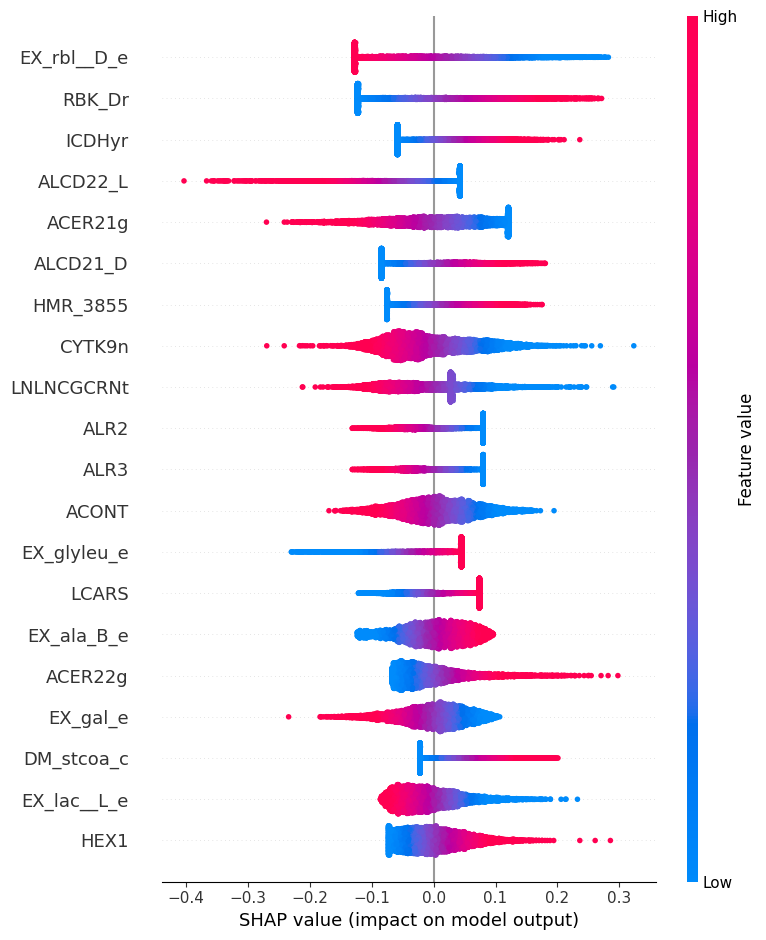

In [28]:
mean_shap_values = np.mean(np.abs(shap_values), axis=0) 

# Step 2: Take the absolute value of the mean SHAP values
#mean_shap_values = np.abs(mean_shap_values)

top_features_indices = list(np.argsort(mean_shap_values)[::-1][:100])

X_test_filtered = X_test.iloc[:, top_features_indices]
shap_values_filtered = shap_values[:, top_features_indices]

shap.summary_plot(shap_values_filtered, X_test_filtered)

In [29]:
mean_shap_values_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': mean_shap_values
})
mean_shap_values_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/SCZ/Shape_values/EN_flux_sampling_100_noTrans/LR/mean_abs_shape_lr_SCZ.csv')



In [30]:
import pickle
# save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100/LR/'
save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/SCZ/Shape_values/EN_flux_sampling_100_noTrans/LR/'

save_path_explainer = save_folder + "LR_shap_explainer_SCZ.pkl"

with open(save_path_explainer, 'wb') as f:
    pickle.dump(explainer, f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = save_folder + "LR_SCZ.pkl"
joblib.dump(final_model, save_path_model)


save_path_shape_values = save_folder + 'LR_shap_values_all_classes_SCZ.npy'
np.save(save_path_shape_values, shap_values)

## Random Forest

In [35]:
# Grouging based on SCZ

G_0 =  data_annoted[data_annoted['SCZ'].isin([0])]
# sample the scz 0
G_0 = G_0.sample(n=18100, random_state=42)

G_1 =  data_annoted[data_annoted['SCZ'].isin([1])]

# Comparsion groups
data_G0_G1 = pd.concat([G_0, G_1], ignore_index=False)
data_G0_G1.fillna(0, inplace=True)

data_HT_AD = data_G0_G1
data_HT_AD.fillna(0, inplace=True)
data_HT_AD.drop(data_HT_AD.columns[-4:-1], axis=1, inplace=True)
filtered_df = data_HT_AD
del data_HT_AD
filtered_df

/tmp/ipykernel_830505/1375434558.py:11: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_4mop_m,DM_pheme_m,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,SCZ
,,,,,,,,,,,,,,,,,,,,,
AMPAD_MSSM_0000077549_EN_521,0.0,1.462950,0.0,0.796232,0,0.0,-4.270616,0,0,1.545885,...,0.0,0.0,0.793557,0.0,0.0,0,0.0,0,0.000000,0
AMPAD_MSSM_0000071187_EN_275,0.0,1.479197,0.0,0.000000,0,0.0,-8.857432,0,0,3.455322,...,0.0,0.0,1.383083,0.0,0.0,0,0.0,0,0.000856,0
AMPAD_MSSM_0000340452_EN_859,0.0,0.982163,0.0,0.000000,0,0.0,-9.390940,0,0,0.000000,...,0.0,0.0,1.967543,0.0,0.0,0,0.0,0,0.000000,0
AMPAD_MSSM_0000042055_EN_451,0.0,2.116122,0.0,0.910982,0,0.0,-1.971951,0,0,1.532204,...,0.0,0.0,1.959734,0.0,0.0,0,0.0,0,0.001265,0
AMPAD_MSSM_0000070658_EN_548,0.0,1.557580,0.0,0.730374,0,0.0,-9.579307,0,0,2.170330,...,0.0,0.0,0.613365,0.0,0.0,0,0.0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_HBCC_0000000448_EN_436,0.0,1.647392,0.0,0.195229,0,0.0,-0.316823,0,0,0.978783,...,0.0,0.0,2.541072,0.0,0.0,0,0.0,0,0.000814,1
AMPAD_HBCC_0000000448_EN_764,0.0,2.977274,0.0,0.867325,0,0.0,-2.420416,0,0,0.442471,...,0.0,0.0,1.702069,0.0,0.0,0,0.0,0,0.000932,1
AMPAD_HBCC_0000000448_EN_88,0.0,1.586071,0.0,0.846646,0,0.0,-4.653852,0,0,0.801324,...,0.0,0.0,0.051689,0.0,0.0,0,0.0,0,0.000741,1


In [36]:
feature_columns = filtered_df.columns.to_list()[:filtered_df.shape[1]-1]
# define tag column
target_column = 'SCZ'

X = filtered_df[feature_columns]
y = filtered_df[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)


In [37]:
def objective(trial):
    # Define the hyperparameter search space
    param = {'n_estimators': trial.suggest_int('n_estimators', 1000,2000),  # Number of trees in the forest
        'max_depth': trial.suggest_int('max_depth', 4, 5, log=True), # Max depth of trees (log scale)
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 4),  # Min samples to split
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),    # Min samples per leaf
        'max_features': trial.suggest_categorical('max_features', [ 'sqrt', 'log2']),  # Features per split
        'bootstrap': trial.suggest_categorical('bootstrap', [True]),  # Whether bootstrap samples are used
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])  # Criterion for split  
                                               }
                                        
            

    # Create the RandomForestClassifier with the suggested parameters
    model = RandomForestClassifier(**param, 
                                   #class_weight='balanced',
                                   random_state=42, 
                                   n_jobs=-1)

    # Fit the model on the training data
    model.fit(X_train, y_train)

    # Get the predicted probabilities on the test set
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)
    
    # Calculate AUC using roc_auc_score
    auc = roc_auc_score(y_test, y_prob)
    
    y_pred = model.predict(X_test)

    # Calculate the accuracy of the model
    accuracy = accuracy_score(y_test, y_pred)
    
    
    return 1 - auc  

study = optuna.create_study(direction='minimize')  # Minimize the objective 
study.optimize(objective, n_trials=5)  # Run the optimization with 50 trials

# Print the best hyperparameters found by Optuna
print("Best hyperparameters found:", study.best_params)

# Print the best AUC score
print("Best score:", 1 - study.best_value)


[I 2025-03-02 09:11:30,746] A new study created in memory with name: no-name-346ba377-b554-423c-ab95-d832941704f8
[I 2025-03-02 09:11:38,812] Trial 0 finished with value: 0.06291390677940234 and parameters: {'n_estimators': 1415, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 0 with value: 0.06291390677940234.
[I 2025-03-02 09:11:42,692] Trial 1 finished with value: 0.06264010561338185 and parameters: {'n_estimators': 1534, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'log_loss'}. Best is trial 1 with value: 0.06264010561338185.
[I 2025-03-02 09:11:49,797] Trial 2 finished with value: 0.06226008058362076 and parameters: {'n_estimators': 1257, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 2 with value: 0.06226008058362076.
[I 

Best hyperparameters found: {'n_estimators': 1257, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}
Best score: 0.9377399194163792


In [39]:
from sklearn.model_selection import cross_val_score

best_params = study.best_params


final_model = RandomForestClassifier(**best_params, 
                                     #class_weight='balanced',
                                     random_state=42, 
                                     n_jobs= -1)

Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
Accuracy = []
F1_score = []
AUC = []
Recall = []
Precision = []
PR_AUC = []
Kappa = []
results = []
fold_num = 0

for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    
    final_model.fit(X_val_train, y_val_train)
    y_pred = final_model.predict(X_val_test)
    y_prob = final_model.predict_proba(X_val_test)[:, 1]  # Probabilities for the positive class (class 1)
    
    accuracy = accuracy_score(y_val_test, y_pred)
    kappa = cohen_kappa_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    pr_auc = average_precision_score(y_val_test, y_prob)
    roc_auc = roc_auc_score(y_val_test, y_prob)
    
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc
    })
    

    
results_df = pd.DataFrame(results)
average_results = {
        "Fold": 'Average',
        "Accuracy": results_df['Accuracy'].mean(),
        "F1-score": results_df['F1-score'].mean(),
        "Recall": results_df['Recall'].mean(),
        "Precision": results_df['Precision'].mean(),
        "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
        "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
    }
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

''' 
    Accuracy.append(accuracy)
    F1_score.append(f1)
    Kappa.append(kappa)
    AUC.append(roc_auc)
    Recall.append(recall)
    Precision.append(precision)
    PR_AUC.append(pr_auc)
'''
results_df


/tmp/ipykernel_830505/1922651237.py:25: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/1922651237.py:25: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/1922651237.py:25: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/1922651237.py:25: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as l

,Fold,Accuracy,F1-score,Recall,Precision,Precision-Recall AUC,AUC (ROC Curve)
0,1,0.859669,0.860974,0.869061,0.853037,0.941065,0.940232
1,2,0.848619,0.850109,0.858564,0.841820,0.939770,0.938991
2,3,0.861602,0.862325,0.866851,0.857846,0.942056,0.942322
3,4,0.860497,0.862360,0.874033,0.850995,0.942242,0.942644
4,5,0.838950,0.837740,0.831492,0.844083,0.932847,0.933031
5,6,0.835359,0.834812,0.832044,0.837597,0.932651,0.930471
6,7,0.840884,0.840178,0.836464,0.843924,0.936114,0.935257
7,8,0.851381,0.850223,0.843646,0.856902,0.943602,0.942146
8,9,0.848619,0.850355,0.860221,0.840713,0.938764,0.938663
9,10,0.850552,0.852468,0.863536,0.841680,0.936364,0.936680


In [40]:
best_params = study.best_params


final_model = RandomForestClassifier(**best_params, 
                                     #class_weight='balanced',
                                     random_state=42, 
                                     n_jobs=-1)
final_model.fit(X_train, y_train)


y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for the positive class (class 1)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. Kappa Score
kappa = cohen_kappa_score(y_test, y_pred)

# 3. F1 Score
f1 = f1_score(y_test, y_pred)

# 4. Recall
recall = recall_score(y_test, y_pred)

# 5. Precision
precision = precision_score(y_test, y_pred)

# 6. Precision-Recall AUC
#precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
#pr_auc = auc(recall_vals, precision_vals)

# 7. AUC (ROC Curve)
roc_auc = roc_auc_score(y_test, y_prob)

# Print the results
print(f"Accuracy: {accuracy}")
print(f"Kappa Score: {kappa}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
#print(f"Precision-Recall AUC: {pr_auc}")
print(f"AUC (ROC Curve): {roc_auc}")


Accuracy: 0.8519337016574585
Kappa Score: 0.7038674033149172
F1 Score: 0.8534718425369054
Recall: 0.8624309392265194
Precision: 0.8446969696969697
AUC (ROC Curve): 0.9377399194163792


In [41]:
explainer = shap.TreeExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

100%|===================| 14453/14480 [08:06<00:00]        

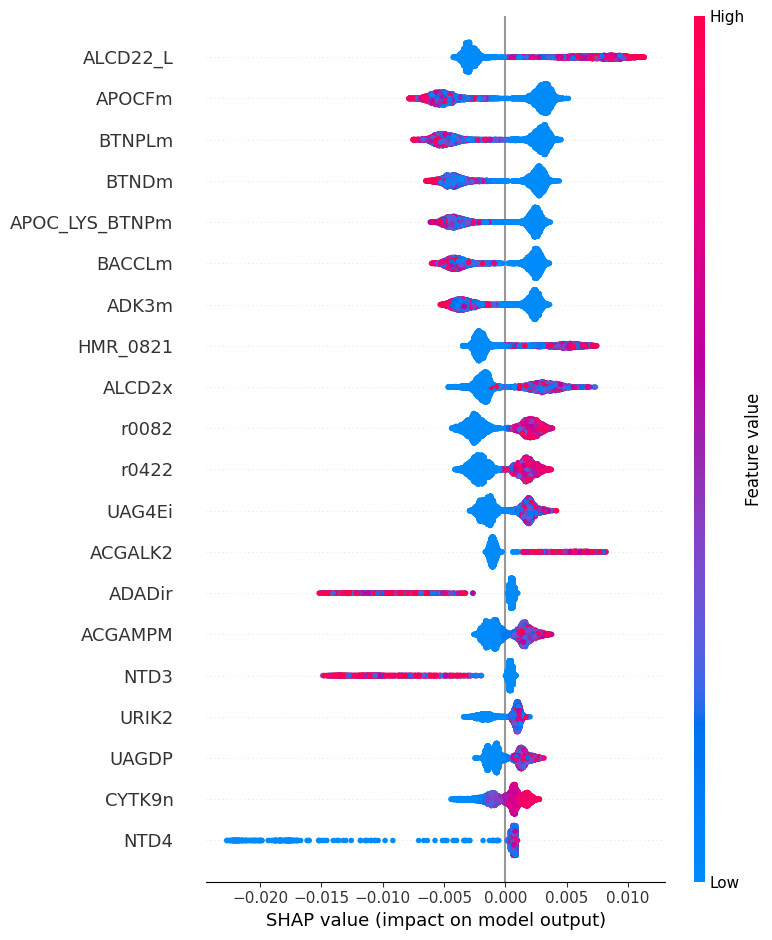

In [42]:
shap_values_class_0 = shap_values[:, :, 0]


mean_shap_values = np.mean(np.abs(shap_values_class_0), axis=0) 

# Step 2: Take the absolute value of the mean SHAP values
#mean_shap_values = np.abs(mean_shap_values)

top_features_indices = list(np.argsort(mean_shap_values)[::-1][:100])

X_test_filtered = X_test.iloc[:, top_features_indices]
shap_values_filtered = shap_values_class_0[:, top_features_indices]

shap.summary_plot(shap_values_filtered, X_test_filtered)

In [43]:
mean_shap_values_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': mean_shap_values
})
mean_shap_values_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/SCZ/Shape_values/EN_flux_sampling_100_noTrans/RF/mean_abs_shape_rf_SCZ.csv')


In [44]:
import pickle
# save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100/LR/'
save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/SCZ/Shape_values/EN_flux_sampling_100_noTrans/RF/'

save_path_explainer = save_folder + "RF_shap_explainer_SCZ.pkl"

with open(save_path_explainer, 'wb') as f:
    pickle.dump(explainer, f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = save_folder + "RF_SCZ.pkl"
joblib.dump(final_model, save_path_model)


save_path_shape_values = save_folder + 'RF_shap_values_all_classes_SCZ.npy'
np.save(save_path_shape_values, shap_values)

## XGBOOST

In [45]:
# Grouging based on SCZ

G_0 =  data_annoted[data_annoted['SCZ'].isin([0])]
# sample the scz 0
G_0 = G_0.sample(n=18100, random_state=42)

G_1 =  data_annoted[data_annoted['SCZ'].isin([1])]

# Comparsion groups
data_G0_G1 = pd.concat([G_0, G_1], ignore_index=False)
data_G0_G1.fillna(0, inplace=True)

data_HT_AD = data_G0_G1
data_HT_AD.fillna(0, inplace=True)
data_HT_AD.drop(data_HT_AD.columns[-4:-1], axis=1, inplace=True)
filtered_df = data_HT_AD
del data_HT_AD
filtered_df

/tmp/ipykernel_830505/1375434558.py:11: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,AGTim,ASNNm,ASNS1,ASPNATm,DASPO1p,NACASPAH,ASPTA,ARGSS,ARGSL,COKECBESr,...,DM_4mop_m,DM_pheme_m,DM_glu__L_syna,DM_4abut_syna,SK_octdececrn_c,DM_glygn2_c,DM_tdechola_c,DM_odecoa_c,DM_stcoa_c,SCZ
,,,,,,,,,,,,,,,,,,,,,
AMPAD_MSSM_0000077549_EN_521,0.0,1.462950,0.0,0.796232,0,0.0,-4.270616,0,0,1.545885,...,0.0,0.0,0.793557,0.0,0.0,0,0.0,0,0.000000,0
AMPAD_MSSM_0000071187_EN_275,0.0,1.479197,0.0,0.000000,0,0.0,-8.857432,0,0,3.455322,...,0.0,0.0,1.383083,0.0,0.0,0,0.0,0,0.000856,0
AMPAD_MSSM_0000340452_EN_859,0.0,0.982163,0.0,0.000000,0,0.0,-9.390940,0,0,0.000000,...,0.0,0.0,1.967543,0.0,0.0,0,0.0,0,0.000000,0
AMPAD_MSSM_0000042055_EN_451,0.0,2.116122,0.0,0.910982,0,0.0,-1.971951,0,0,1.532204,...,0.0,0.0,1.959734,0.0,0.0,0,0.0,0,0.001265,0
AMPAD_MSSM_0000070658_EN_548,0.0,1.557580,0.0,0.730374,0,0.0,-9.579307,0,0,2.170330,...,0.0,0.0,0.613365,0.0,0.0,0,0.0,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMPAD_HBCC_0000000448_EN_436,0.0,1.647392,0.0,0.195229,0,0.0,-0.316823,0,0,0.978783,...,0.0,0.0,2.541072,0.0,0.0,0,0.0,0,0.000814,1
AMPAD_HBCC_0000000448_EN_764,0.0,2.977274,0.0,0.867325,0,0.0,-2.420416,0,0,0.442471,...,0.0,0.0,1.702069,0.0,0.0,0,0.0,0,0.000932,1
AMPAD_HBCC_0000000448_EN_88,0.0,1.586071,0.0,0.846646,0,0.0,-4.653852,0,0,0.801324,...,0.0,0.0,0.051689,0.0,0.0,0,0.0,0,0.000741,1


In [46]:
feature_columns = filtered_df.columns.to_list()[:filtered_df.shape[1]-1]
# define tag column
target_column = 'SCZ'

X = filtered_df[feature_columns]
y = filtered_df[target_column]

scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X = pd.DataFrame(X, columns=feature_columns)
# Split the data into training and test sets(8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=100, stratify=y, shuffle=True)


In [49]:
def hyperopt_objective(params):

    params['objective'] = 'binary:logistic'
    params['eval_metric'] = 'logloss'
  
    
    evallist = [(X_train, y_train), X_test, y_test]
        
    # Train the model with early stopping based on validation data
    model = xgb.XGBClassifier(
        n_estimators = int(params['n_estimators']),
        max_depth = int(params['max_depth']),
        eta = params['eta'],
        gamma = params['gamma'],
        subsample = params['subsample'],
        colsample_bytree = params['colsample_bytree'],
        reg_lambda = params['lambda'],
        reg_alpha = params['alpha'],
        early_stopping_rounds=int(params['n_estimators'])*0.1,
        eval_metric = 'logloss',
        #scale_pos_weight = params['scale_pos_weight'],
        #max_delta_step = params['max_delta_step'],
        n_jobs = -1
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        
        verbose=False)
    
    # Get predictions on the validation set and compute AUC
    
    y_pred = model.predict(X_test)

  
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    #auc = roc_auc_score(y_test, y_pred_prob)  # Calculate ROC AUC for validation set
        
   
    
    # Return the negative of the average AUC score across all folds
   
    return {'loss': -accuracy, 'status': STATUS_OK}


from hyperopt.pyll.base import scope

params_space = {
            'gamma': hp.loguniform('gamma', np.log(0.0001), np.log(3)) - 0.0001,
            'max_depth': scope.int(hp.uniform('max_depth', 1, 4)),
            'subsample': hp.uniform('subsample', 0.5, 0.8),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.7),
            'colsample_bylevel': hp.uniform('colsample_bylevel', 0.5, 0.7),
            'lambda': hp.loguniform('lambda', np.log(1), np.log(4)),
            'alpha': hp.loguniform('alpha', np.log(0.8), np.log(1)) - 0.0001,
            'eta': hp.loguniform('eta', np.log(0.3), np.log(0.5)),
            #'scale_pos_weight': hp.uniform('scale_pos_weight',1.2,1.3),
            #'scale_pos_weight': hp.uniform('scale_pos_weight',0.4,0.6),
            #'max_delta_step':hp.uniform('max_delta_step', 0, 5),
            'n_estimators': hp.randint('n_estimators', 10, 500)
            
                     }


trials = Trials()

rng = default_rng(123)

best = fmin(
    hyperopt_objective,         # The objective function to minimize
    space=params_space,         # The hyperparameter search space
    algo=tpe.suggest,           # The algorithm for optimization
    max_evals=3,                # Number of trials to evaluate
    trials=trials,              # Store the results of each trial
    rstate=rng                  # Random state for reproducibility
)

  0%|                                     | 0/3 [00:00<?, ?trial/s, best loss=?]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.001552 seconds
INFO:hyperopt.tpe:TPE using 0 trials


 33%|███▎      | 1/3 [00:06<00:12,  6.41s/trial, best loss: -0.8117403314917127]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.001568 seconds
INFO:hyperopt.tpe:TPE using 1/1 trials with best loss -0.811740


 67%|██████▋   | 2/3 [00:25<00:13, 13.80s/trial, best loss: -0.9965469613259669]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.001809 seconds
INFO:hyperopt.tpe:TPE using 2/2 trials with best loss -0.996547


100%|██████████| 3/3 [00:42<00:00, 14.26s/trial, best loss: -0.9965469613259669]


In [51]:
# xbgclassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score,precision_recall_curve, auc
# Prepare the StratifiedKFold
Stratified_kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Create empty lists to store metrics
results = []
fold_num = 0

# Loop through each fold for cross-validation
for train_index, test_index in Stratified_kf.split(X, y):
    fold_num += 1
    X_val_train, X_val_test = X.iloc[train_index], X.iloc[test_index]
    y_val_train, y_val_test = y[train_index], y[test_index]
    

    
    # Train the model using xgb.train
    final_model = xgb.XGBClassifier(
        n_estimators = int(best['n_estimators']),
        max_depth = int(best['max_depth']),
        eta = best['eta'],
        gamma = best['gamma'],
        subsample = best['subsample'],
        colsample_bytree = best['colsample_bytree'],
        reg_lambda = best['lambda'],
        reg_alpha = best['alpha'],
        early_stopping_rounds=int(best['n_estimators'])*0.1,
        eval_metric = 'logloss',
        #scale_pos_weight = best['scale_pos_weight'],
        #max_delta_step = best['max_delta_step'],
        n_jobs = -1
        
    )
    

    final_model.fit(X_val_train, y_val_train,
                   eval_set=[(X_val_test, y_val_test)],
                   verbose=False)
    
    # Make predictions
    y_pred = final_model.predict(X_val_test)
    y_pre_prob = final_model.predict_proba(X_val_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_val_test, y_pred)
    f1 = f1_score(y_val_test, y_pred)
    recall = recall_score(y_val_test, y_pred)
    precision = precision_score(y_val_test, y_pred)
    precision_values, recall_values, _ = precision_recall_curve(y_val_test, y_pre_prob)
    pr_auc = auc(recall_values, precision_values)
    roc_auc = roc_auc_score(y_val_test, y_pre_prob)
    
    # Store results for each fold
    results.append({
        "Fold": fold_num,
        "Accuracy": accuracy,
        "F1-score": f1,
        "Recall": recall,
        "Precision": precision,
        "Precision-Recall AUC": pr_auc,
        "AUC (ROC Curve)": roc_auc

    })

# Create a DataFrame from the results of each fold
results_df = pd.DataFrame(results)

# Calculate average results across all folds
average_results = {
    "Fold": 'Average',
    "Accuracy": results_df['Accuracy'].mean(),
    "F1-score": results_df['F1-score'].mean(),
    "Recall": results_df['Recall'].mean(),
    "Precision": results_df['Precision'].mean(),
    "Precision-Recall AUC": results_df['Precision-Recall AUC'].mean(),
    "AUC (ROC Curve)": results_df['AUC (ROC Curve)'].mean()
}

# Add the average results to the DataFrame
average_df = pd.DataFrame([average_results])
results_df = pd.concat([results_df, average_df], ignore_index=True)

# Display the final results
results_df

/tmp/ipykernel_830505/3770865369.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/3770865369.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/3770865369.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_830505/3770865369.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as l

,Fold,Accuracy,F1-score,Recall,Precision,Precision-Recall AUC,AUC (ROC Curve)
0,1,0.997238,0.997239,0.997790,0.996689,0.999963,0.999962
1,2,0.998066,0.998068,0.998895,0.997242,0.999928,0.999932
2,3,0.998895,0.998895,0.998895,0.998895,0.999982,0.999982
3,4,0.998619,0.998619,0.998895,0.998343,0.999922,0.999919
4,5,0.996409,0.996412,0.997238,0.995587,0.999913,0.999911
5,6,0.998619,0.998620,0.999448,0.997794,0.999991,0.999991
6,7,0.998619,0.998620,0.999448,0.997794,0.999681,0.999748
7,8,0.997790,0.997791,0.998343,0.997241,0.999956,0.999955
8,9,0.998343,0.998343,0.998343,0.998343,0.999904,0.999896
9,10,0.998343,0.998344,0.999448,0.997244,0.999980,0.999980


In [52]:
# xbgClassifier

final_model = xgb.XGBClassifier(
    n_estimators = int(best['n_estimators']),
    max_depth = int(best['max_depth']),
    eta = best['eta'],
    gamma = best['gamma'],
    subsample = best['subsample'],
    colsample_bytree = best['colsample_bytree'],
    reg_lambda = best['lambda'],
    reg_alpha = best['alpha'],
    early_stopping_rounds=int(best['n_estimators'])*0.1,
    eval_metric = 'logloss',
    #scale_pos_weight = best['scale_pos_weight'],
    #max_delta_step = best['max_delta_step'],
    n_jobs = -1
        
)
    

final_model.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False)


y_pred = final_model.predict(X_test)
y_pre_prob = final_model.predict_proba(X_test)[:, 1]
    
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
precision_values, recall_values, _ = precision_recall_curve(y_test, y_pre_prob)
pr_auc = auc(recall_values, precision_values)
roc_auc = roc_auc_score(y_test, y_pre_prob)



print("XGBoost Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)
print("Precision-Recall Curve:", pr_auc)
print("AUC:", roc_auc)

XGBoost Accuracy: 0.9965469613259669
F1 Score: 0.9965493443754313
Recall: 0.9972375690607734
Precision: 0.9958620689655172
Precision-Recall Curve: 0.9998666388286244
AUC: 0.9998325753182138


In [54]:
explainer = shap.TreeExplainer(final_model, X_train)
shap_values = explainer.shap_values(X_test)

 99%|===================| 7146/7240 [00:29<00:00]        

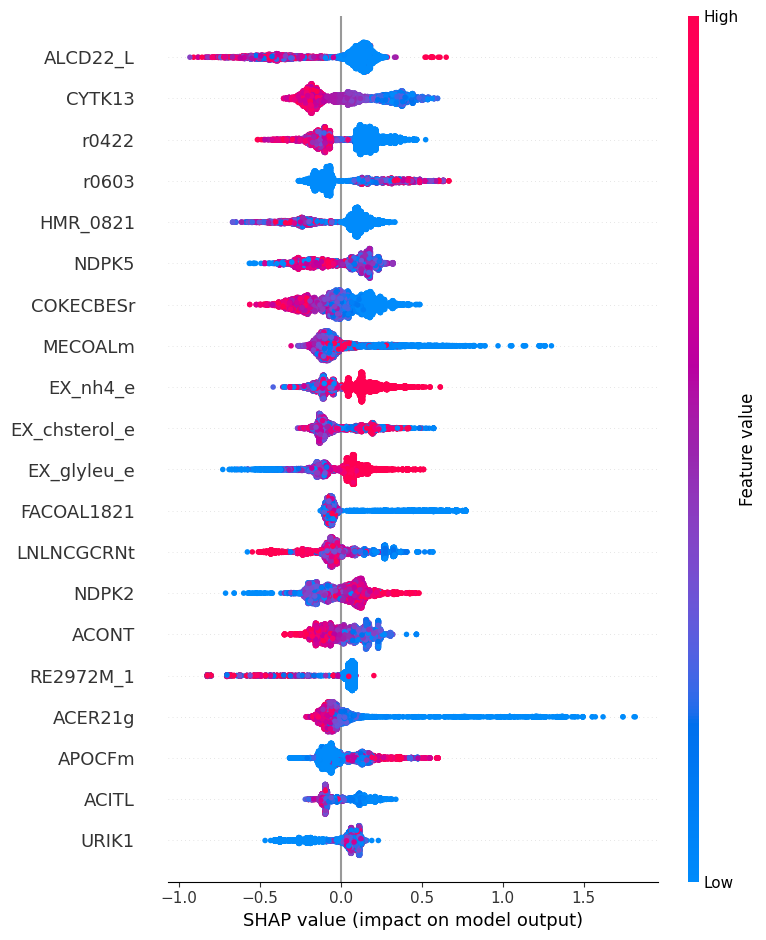

In [55]:
shap_values_class_0 = shap_values


mean_shap_values = np.mean(np.abs(shap_values_class_0), axis=0) 

# Step 2: Take the absolute value of the mean SHAP values
#mean_shap_values = np.abs(mean_shap_values)

top_features_indices = list(np.argsort(mean_shap_values)[::-1][:100])

X_test_filtered = X_test.iloc[:, top_features_indices]
shap_values_filtered = shap_values_class_0[:, top_features_indices]

shap.summary_plot(shap_values_filtered, X_test_filtered)

In [56]:
mean_shap_values_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean SHAP Value': mean_shap_values
})
mean_shap_values_df.to_csv('/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/SCZ/Shape_values/EN_flux_sampling_100_noTrans/XGBOOST/mean_abs_shape_xgboost_SCZ.csv')


In [57]:
import pickle
# save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/ML/Shape_values/EN_flux_sampling_100/LR/'
save_folder = '/depot/pbaloni/data/Lab_members/Boyu_Jiang/Neuron_GEM/Case_Studies_manuscript/NPS_AD/Analysis_outputs/SCZ/Shape_values/EN_flux_sampling_100_noTrans/XGBOOST/'

save_path_explainer = save_folder + "XGBOOST_shap_explainer_SCZ.pkl"

with open(save_path_explainer, 'wb') as f:
    pickle.dump(explainer, f)

import joblib

# Save the trained logistic regression model to a file
save_path_model = save_folder + "XGBOOST_SCZ.pkl"
joblib.dump(final_model, save_path_model)


save_path_shape_values = save_folder + 'XGBOOST_shap_values_all_classes_SCZ.npy'
np.save(save_path_shape_values, shap_values)